In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Dataset/processed_dataset.csv")

print(df.shape)
df.head()

(10000, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,35510.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,25734.0,84.0,2.0,2.0,4.0,12.0,2.0,2.0,2.0,0.0,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,53.0,240.0,2.0,2.0,68.0,292.0,34.0,34.0,34.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,53.0,48009.0,1.0,1.0,55.0,110.0,55.0,55.0,55.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,40382.0,54.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [6]:
df.tail(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
9990,80.0,934044.0,3.0,5.0,26.0,11607.0,20.0,0.0,8.666667,10.263203,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
9991,80.0,7853848.0,4.0,0.0,24.0,0.0,6.0,6.0,6.000000,0.000000,...,20.0,2003.0,0.0,2003.0,2003.0,7851845.0,0.0,7851845.0,7851845.0,1
9992,80.0,10267191.0,5.0,5.0,312.0,3525.0,312.0,0.0,62.400000,139.530642,...,32.0,859.0,0.0,859.0,859.0,5261864.0,0.0,5261864.0,5261864.0,1
9993,38292.0,62.0,1.0,1.0,2.0,6.0,2.0,2.0,2.000000,0.000000,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
9994,80.0,84451147.0,6.0,6.0,324.0,11595.0,324.0,0.0,54.000000,132.272446,...,32.0,6.0,0.0,6.0,6.0,84300000.0,0.0,84300000.0,84300000.0,1
9995,22.0,10807915.0,21.0,32.0,2008.0,2745.0,640.0,0.0,95.619048,140.045163,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
9996,80.0,81791431.0,8.0,5.0,56.0,11601.0,20.0,0.0,7.000000,5.656854,...,20.0,933.0,0.0,933.0,933.0,40300000.0,40100000.0,68700000.0,11900000.0,1
9997,80.0,81248557.0,8.0,5.0,56.0,11607.0,20.0,0.0,7.000000,5.656854,...,20.0,5009.0,0.0,5009.0,5009.0,40500000.0,48800000.0,75000000.0,6023859.0,1
9998,80.0,85137518.0,8.0,7.0,354.0,11595.0,354.0,0.0,44.250000,125.157900,...,32.0,3998.0,0.0,3998.0,3998.0,85000000.0,0.0,85000000.0,85000000.0,1
9999,80.0,38708.0,3.0,4.0,26.0,11601.0,20.0,0.0,8.666667,10.263203,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [8]:
# 4. Split Features and Target
X = df.drop('Label', axis=1)
y = df['Label']

In [9]:
# 5. Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# 6. Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# 7. Build Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [12]:
# 8. Predictions
y_pred = model.predict(X_test)

In [13]:
# 9. Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9385

Confusion Matrix:
[[949  63]
 [ 60 928]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1012
           1       0.94      0.94      0.94       988

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



Text(50.722222222222214, 0.5, 'Actual')

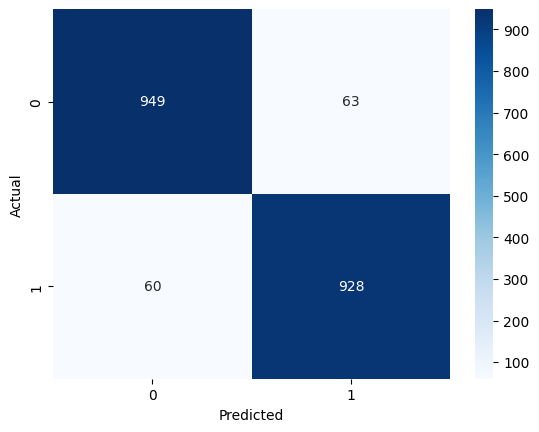

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d',
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score # Added this import


pipe = Pipeline([ # prevent data leakage (without it, the scaler and PCA would be fitted on the whole dataset, including the test set)
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('model', LogisticRegression(max_iter=1000))
])

scores = cross_val_score(pipe, X, y, cv=5)

print(scores)
print(scores.mean())

[0.7865 0.7685 0.7725 0.763  0.7805]
0.7741999999999999


In [23]:
from sklearn.model_selection import cross_validate

results = cross_validate(
    pipe,
    X,
    y,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=True
)

print(results)

{'fit_time': array([0.09498978, 0.058496  , 0.06940699, 0.09625602, 0.11054206]), 'score_time': array([0.04326868, 0.01796389, 0.01759291, 0.02498269, 0.02719688]), 'test_accuracy': array([0.7865, 0.7685, 0.7725, 0.763 , 0.7805]), 'train_accuracy': array([0.789375, 0.768375, 0.769875, 0.776375, 0.769   ]), 'test_precision': array([0.87747036, 0.83271375, 0.83435583, 0.83631714, 0.85641677]), 'train_precision': array([0.88391376, 0.83431953, 0.83850737, 0.84687794, 0.84115409]), 'test_recall': array([0.666, 0.672, 0.68 , 0.654, 0.674]), 'train_recall': array([0.66625, 0.66975, 0.6685 , 0.67475, 0.66325]), 'test_f1': array([0.75724844, 0.74377421, 0.74931129, 0.73400673, 0.75433688]), 'train_f1': array([0.75980043, 0.74303148, 0.74391431, 0.75107834, 0.74168297])}


In [24]:
print(results['train_accuracy'].mean())
print(results['test_accuracy'].mean())

0.7746000000000001
0.7741999999999999


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **la

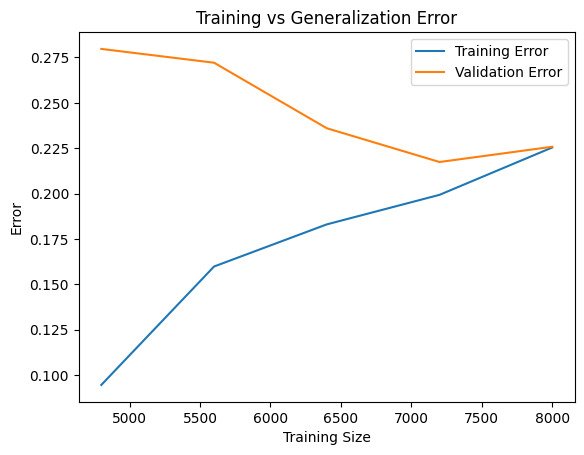

In [25]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipe, X, y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# calculate mean scores
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# convert to error
train_error = 1 - train_mean
val_error = 1 - val_mean

# plot learning curves
plt.plot(train_sizes, train_error, label="Training Error")
plt.plot(train_sizes, val_error, label="Validation Error")

plt.xlabel("Training Size")
plt.ylabel("Error")
plt.title("Training vs Generalization Error")
plt.legend()
plt.show()